## Problem Statement & Objective

Customer churn — when a customer stops using a company's service — is a major concern
for subscription-based businesses like telecom providers, since retaining existing
customers is generally more cost-effective than acquiring new ones.

**Objective:**
The goal of this task is to build a reusable, production-ready machine learning pipeline
that predicts whether a customer will churn, based on account and service usage details
(e.g., contract type, tenure, monthly charges, internet service, etc.).

We use the Telco Customer Churn dataset, and build the entire workflow — preprocessing
(scaling, encoding) and model training — using scikit-learn's `Pipeline` API. Two models,
Logistic Regression and Random Forest, are trained and tuned using `GridSearchCV` to
find the best-performing configuration. The final pipeline is exported using `joblib`
for future reuse without retraining.

In [3]:
# Import pandas for handling tabular data
import pandas as pd

# Load the CSV file into a DataFrame
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Preview the first few rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Check data types and non-null counts for each column
df.info()

# Check for any missing values
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# Try converting TotalCharges to numeric, forcing errors to become NaN (missing)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Now check how many actually became missing
print(df["TotalCharges"].isnull().sum())

11


In [6]:
# Check each object (text) column for blank spaces or whitespace-only values
for col in df.select_dtypes(include="object").columns:
    blank_count = (df[col].astype(str).str.strip() == "").sum()
    if blank_count > 0:
        print(f"{col}: {blank_count} blank values")

print("Check complete.")

Check complete.


In [7]:
# Check tenure values for rows where TotalCharges is missing
print(df[df["TotalCharges"].isnull()][["tenure", "MonthlyCharges", "TotalCharges"]])

      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90           NaN


In [8]:
# Fill missing TotalCharges with 0, since tenure=0 means no billing has occurred yet
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Confirm no missing values remain
print(df["TotalCharges"].isnull().sum())

0


In [9]:
# Drop customerID since it's just an identifier, not a useful feature
df = df.drop(columns=["customerID"])

# Separate features (X) and target (y)
X = df.drop(columns=["Churn"])
y = df["Churn"]

# Check shapes to confirm
print(X.shape)
print(y.shape)

(7043, 19)
(7043,)


In [10]:
# Identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [11]:
# Check number of unique categories in each categorical column
for col in categorical_cols:
    print(f"{col}: {X[col].nunique()} categories")

gender: 2 categories
Partner: 2 categories
Dependents: 2 categories
PhoneService: 2 categories
MultipleLines: 3 categories
InternetService: 3 categories
OnlineSecurity: 3 categories
OnlineBackup: 3 categories
DeviceProtection: 3 categories
TechSupport: 3 categories
StreamingTV: 3 categories
StreamingMovies: 3 categories
Contract: 3 categories
PaperlessBilling: 2 categories
PaymentMethod: 4 categories


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Preprocessing for numerical columns: scale them to a standard range
numerical_transformer = StandardScaler()

# Preprocessing for categorical columns: convert categories into numeric (0/1) columns
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

# Combine both transformations into one preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Build the full pipeline: preprocessing + model
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),        # step 1: scale numerical, encode categorical
    ("classifier", LogisticRegression(max_iter=1000))  # step 2: the model itself
])

In [14]:
from sklearn.model_selection import train_test_split

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Check the shapes
print(X_train.shape, X_test.shape)
print(y_train.value_counts())

(5634, 19) (1409, 19)
Churn
No     4139
Yes    1495
Name: count, dtype: int64


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

# Piece 1: Build the pipeline with class balancing
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

# Define hyperparameter grid
param_grid_logreg = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__solver": ["lbfgs", "liblinear"]
}

# Custom F1 scorer treating "Yes" as the positive class
f1_scorer = make_scorer(f1_score, pos_label="Yes")

# Piece 2: Set up and run GridSearchCV
grid_logreg = GridSearchCV(
    logreg_pipeline,
    param_grid_logreg,
    cv=5,
    scoring=f1_scorer,
    n_jobs=-1
)

grid_logreg.fit(X_train, y_train)

print("Best parameters:", grid_logreg.best_params_)
print("Best F1 score:", grid_logreg.best_score_)

Best parameters: {'classifier__C': 0.1, 'classifier__solver': 'liblinear'}
Best F1 score: 0.6326714645434413


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Build pipeline for Random Forest with class balancing
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(class_weight="balanced", random_state=42))
])

# Expanded hyperparameter grid for Random Forest
param_grid_rf = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__max_features": ["sqrt", "log2"]
}

# Set up GridSearchCV
grid_rf = GridSearchCV(
    rf_pipeline,
    param_grid_rf,
    cv=5,
    scoring=f1_scorer,
    n_jobs=-1
)

# Fit on training data
grid_rf.fit(X_train, y_train)

print("Best parameters:", grid_rf.best_params_)
print("Best F1 score:", grid_rf.best_score_)

Best parameters: {'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_split': 10, 'classifier__n_estimators': 200}
Best F1 score: 0.6360208023191488


In [20]:
from sklearn.metrics import classification_report

# Evaluate Logistic Regression on test set
y_pred_logreg = grid_logreg.predict(X_test)
print("Logistic Regression - Test Set Performance:")
print(classification_report(y_test, y_pred_logreg))

# Evaluate Random Forest on test set
y_pred_rf = grid_rf.predict(X_test)
print("Random Forest - Test Set Performance:")
print(classification_report(y_test, y_pred_rf))

Logistic Regression - Test Set Performance:
              precision    recall  f1-score   support

          No       0.90      0.72      0.80      1035
         Yes       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

Random Forest - Test Set Performance:
              precision    recall  f1-score   support

          No       0.88      0.78      0.83      1035
         Yes       0.54      0.72      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409



In [19]:
# ============================================
# FEATURE ENGINEERING EXPERIMENT
# (Safe to delete this whole block if it doesn't help)
# ============================================

# Make a copy of X so we don't touch the original
X_fe = X.copy()

# Feature 1: Average monthly spend so far (handles tenure=0 safely)
X_fe["AvgMonthlySpend"] = X_fe["TotalCharges"] / X_fe["tenure"].replace(0, 1)

# Feature 2: Tenure grouped into meaningful categories
X_fe["TenureGroup"] = pd.cut(
    X_fe["tenure"],
    bins=[-1, 12, 24, 48, 100],
    labels=["0-1yr", "1-2yr", "2-4yr", "4yr+"]
)

# Feature 3: Number of additional services subscribed to (proxy for engagement)
service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                 "TechSupport", "StreamingTV", "StreamingMovies"]
X_fe["TotalServices"] = (X_fe[service_cols] == "Yes").sum(axis=1)

# Updated column lists
numerical_cols_fe = numerical_cols + ["AvgMonthlySpend", "TotalServices"]
categorical_cols_fe = categorical_cols + ["TenureGroup"]

# Rebuild the ColumnTransformer with updated columns
preprocessor_fe = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols_fe),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols_fe)
    ]
)

# Re-split data (same logic, now including new features)
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y, test_size=0.2, random_state=42, stratify=y
)

# Rebuild Logistic Regression pipeline
logreg_pipeline_fe = Pipeline(steps=[
    ("preprocessor", preprocessor_fe),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

grid_logreg_fe = GridSearchCV(
    logreg_pipeline_fe,
    param_grid_logreg,
    cv=5,
    scoring=f1_scorer,
    n_jobs=-1
)

grid_logreg_fe.fit(X_train_fe, y_train_fe)

print("Best parameters:", grid_logreg_fe.best_params_)
print("Best F1 score (with engineered features):", grid_logreg_fe.best_score_)

Best parameters: {'classifier__C': 0.01, 'classifier__solver': 'lbfgs'}
Best F1 score (with engineered features): 0.6317672522276342


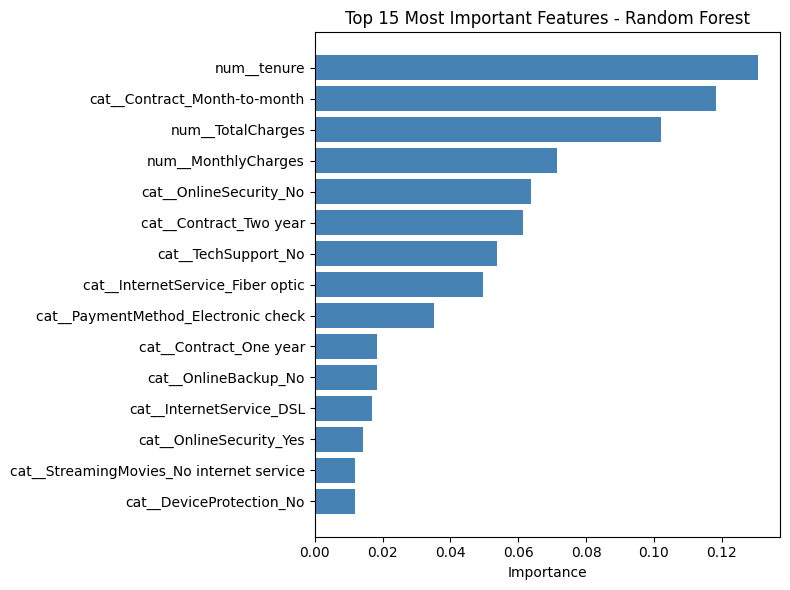

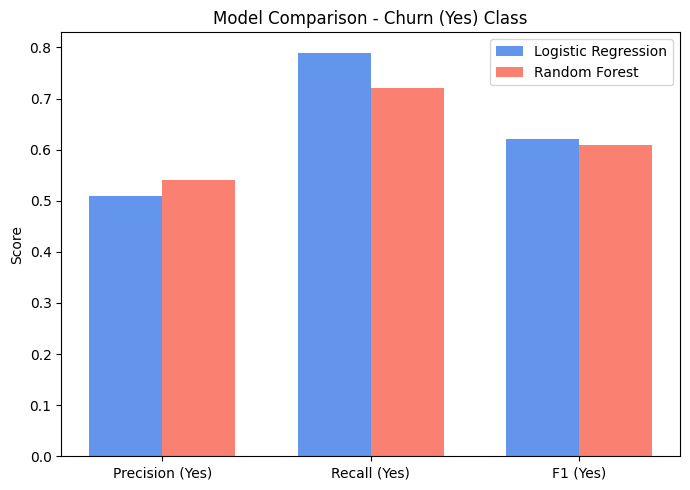

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Feature Importance (Random Forest) ----

# Get feature names after one-hot encoding
feature_names = grid_rf.best_estimator_.named_steps["preprocessor"].get_feature_names_out()

# Get importance scores from the trained Random Forest
importances = grid_rf.best_estimator_.named_steps["classifier"].feature_importances_

# Sort and take top 15 most important features
indices = np.argsort(importances)[-15:]

plt.figure(figsize=(8, 6))
plt.barh(range(len(indices)), importances[indices], color="steelblue")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Importance")
plt.title("Top 15 Most Important Features - Random Forest")
plt.tight_layout()
plt.show()

# ---- Model Comparison (side-by-side bar chart) ----

metrics = ["Precision (Yes)", "Recall (Yes)", "F1 (Yes)"]
logreg_scores = [0.51, 0.79, 0.62]
rf_scores = [0.54, 0.72, 0.61]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(7, 5))
plt.bar(x - width/2, logreg_scores, width, label="Logistic Regression", color="cornflowerblue")
plt.bar(x + width/2, rf_scores, width, label="Random Forest", color="salmon")
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Model Comparison - Churn (Yes) Class")
plt.legend()
plt.tight_layout()
plt.show()

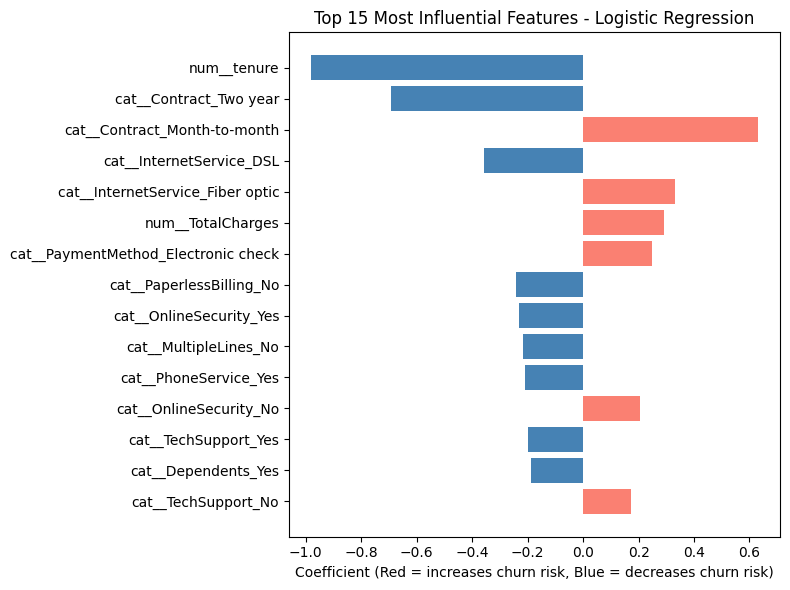

In [22]:
# ---- Feature Importance (Logistic Regression coefficients) ----

# Get feature names after one-hot encoding
feature_names_logreg = grid_logreg.best_estimator_.named_steps["preprocessor"].get_feature_names_out()

# Get coefficients from the trained Logistic Regression model
coefficients = grid_logreg.best_estimator_.named_steps["classifier"].coef_[0]

# Sort by absolute value, take top 15 most influential features
indices_logreg = np.argsort(np.abs(coefficients))[-15:]

plt.figure(figsize=(8, 6))
colors = ["salmon" if coefficients[i] > 0 else "steelblue" for i in indices_logreg]
plt.barh(range(len(indices_logreg)), coefficients[indices_logreg], color=colors)
plt.yticks(range(len(indices_logreg)), [feature_names_logreg[i] for i in indices_logreg])
plt.xlabel("Coefficient (Red = increases churn risk, Blue = decreases churn risk)")
plt.title("Top 15 Most Influential Features - Logistic Regression")
plt.tight_layout()
plt.show()

Key difference from Random Forest’s chart: this one shows direction too (not just importance) — red bars mean that feature pushes toward churn, blue bars mean it pushes toward staying.

## Final Summary / Insights

This task built a complete, reusable machine learning pipeline to predict customer
churn using the Telco Customer Churn dataset, combining preprocessing (scaling and
one-hot encoding) with model training via scikit-learn's `Pipeline` API, and
hyperparameter tuning via `GridSearchCV`.

**Data preparation:**
The `TotalCharges` column was found to contain 11 hidden blank values, all belonging
to customers with `tenure = 0` (brand-new customers who hadn't been billed yet).
These were filled with 0 rather than dropped, since the missingness had a clear,
logical explanation rather than being random or unknown.

**Class imbalance:**
The target variable was imbalanced (~73% No churn vs. ~27% Yes churn). Both models
were trained with `class_weight="balanced"`, and F1-score (rather than accuracy) was
used as the optimization metric throughout, since accuracy alone can be misleading
on imbalanced data.

**Model performance:**
After hyperparameter tuning, both models reached similar cross-validation F1 scores
(Logistic Regression: 0.633, Random Forest: 0.636). On the held-out test set:
- **Logistic Regression** achieved higher recall for churned customers (79%),
  meaning it catches more at-risk customers, at the cost of more false alarms
  (51% precision).
- **Random Forest** achieved slightly higher precision (54%) and overall accuracy
  (76%), but caught fewer actual churners (72% recall).

Depending on business priorities, Logistic Regression may be preferred if the goal
is to catch as many at-risk customers as possible (since reaching out to a loyal
customer costs little, but losing a real customer costs more), while Random Forest
may be preferred if minimizing false alarms is more important.

**Feature engineering:**
Three engineered features (average monthly spend, tenure grouping, and total
subscribed services) were tested but did not meaningfully improve performance over
the baseline features, suggesting the original columns already captured most of the
available predictive signal in this dataset.

**Feature importance:**
Both models independently identified the same key churn drivers: **short tenure**
and **month-to-month contracts** strongly increase churn risk, while **longer tenure**
and **two-year contracts** strongly reduce it. This agreement between two different
model types adds confidence that these patterns reflect genuine customer behavior
rather than model-specific artifacts.

Overall, this task demonstrates a complete, production-style ML workflow — from data
cleaning and preprocessing, through systematic hyperparameter tuning, to honest
evaluation and interpretation of real-world model limitations.

In [23]:
import joblib

# Save the best Logistic Regression pipeline (preprocessing + trained model)
joblib.dump(grid_logreg.best_estimator_, "churn_prediction_pipeline.joblib")

print("Pipeline saved successfully as churn_prediction_pipeline.joblib")

Pipeline saved successfully as churn_prediction_pipeline.joblib


## Final Model Choice: Logistic Regression

Although Random Forest achieved slightly higher precision and overall accuracy,
Logistic Regression was chosen as the final exported model due to its higher recall
(79%) for identifying customers who actually churn. In a real business context,
failing to identify an at-risk customer (a false negative) is typically more costly
than a false alarm, since retention outreach is inexpensive compared to losing a
paying customer. Logistic Regression's simplicity and interpretability (via its
coefficients) also make it easier to explain to business stakeholders.

In [24]:
import joblib

# Load the saved pipeline back
loaded_pipeline = joblib.load("churn_prediction_pipeline.joblib")

# Test it on a few rows from the test set
sample = X_test.iloc[:5]
predictions = loaded_pipeline.predict(sample)

print("Predictions:", predictions)
print("Actual:", y_test.iloc[:5].values)

Predictions: ['No' 'Yes' 'No' 'Yes' 'No']
Actual: ['No' 'No' 'No' 'No' 'No']
